In [116]:
from src.utils.helpers import read_image_as_numpyimage
from src.utils.plotting import display_img
from pathlib import Path
from src import config
import cv2
import numpy as np
from src.utils.lines import Line, LineGroup, group_lines

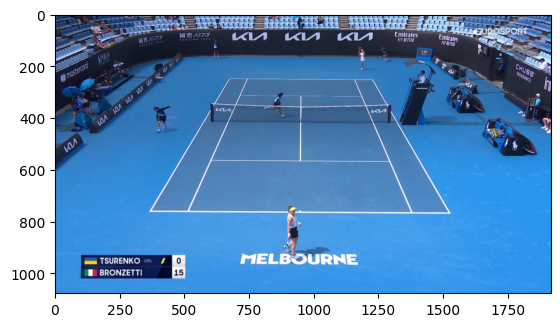

In [117]:
pics_dir = Path('../data/pics')

for pic in pics_dir.glob('*.png'):

    img = read_image_as_numpyimage(pic)

    display_img(img)

    break

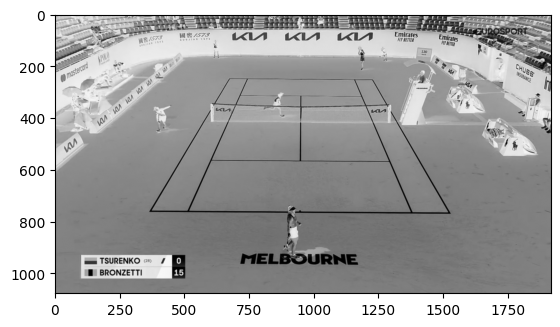

In [118]:
img_gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
img_inv = 255 - img_gray
display_img(img_inv)

In [ ]:
edges = cv2.Canny(img_gray, 50, 200)

segments = cv2.HoughLinesP(
    edges,
    rho=1,
    theta=np.pi / 180,
    threshold=100,
    minLineLength=100,
    maxLineGap=10
)

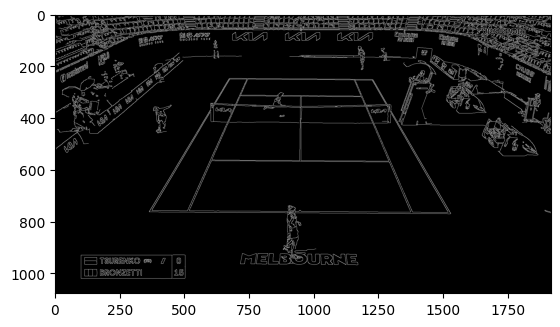

In [147]:
display_img(edges)

In [148]:
img_copy = img.copy()
if segments is not None:
    for line in segments:
        x1, y1, x2, y2 = line[0]
        cv2.line(img_copy, (x1, y1), (x2, y2), (0, 255, 0), 2)

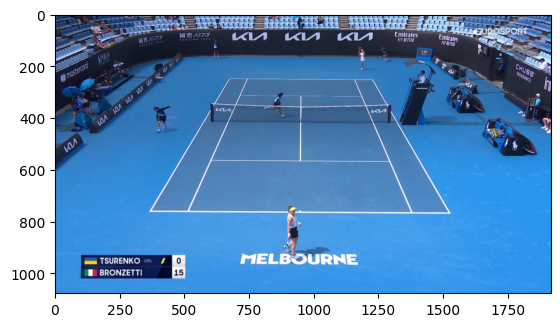

In [149]:
display_img(img_copy)

In [123]:
# filtrowanie tych segmentow blizej osi obrazka
h, w = img.height, img.width
center_x = w // 2

filtered = []

for line in segments:
    x1, y1, x2, y2 = line[0]

    # środek segmentu
    mx = (x1 + x2) / 2

    # odległość od osi pionowej
    dist = abs(mx - center_x)

    # próg
    if dist < 100:
        filtered.append(line)

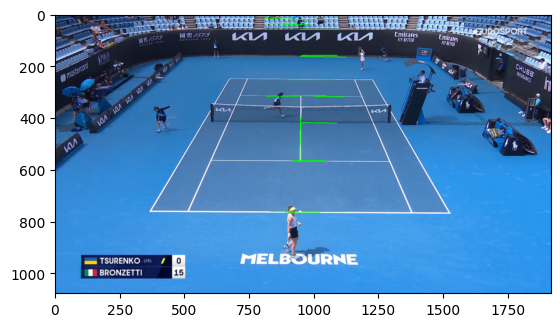

In [124]:
img_copy = img.copy()

for line in filtered:
    x1, y1, x2, y2 = line[0]
    cv2.line(img_copy, (x1, y1), (x2, y2), (0, 255, 0), 2)

display_img(img_copy)

In [125]:
lines = [Line.from_hough_line(*segment) for segment in segments]

In [126]:
img_copy = img.copy()

for line in lines:

    p1, p2 = line.limit_to_img(img_copy)

    cv2.line(img_copy, p1, p2, (255, 0, 0), 1)

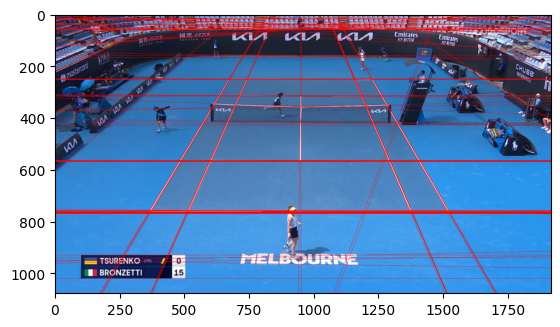

In [127]:
display_img(img_copy)

In [128]:
h_lines = [line for line in lines if line.slope is not None and abs(line.slope) < 0.1]

In [129]:
img_copy = img.copy()

for line in h_lines:

    p1, p2 = line.limit_to_img(img_copy)

    cv2.line(img_copy, p1, p2, (255, 0, 0), 1)

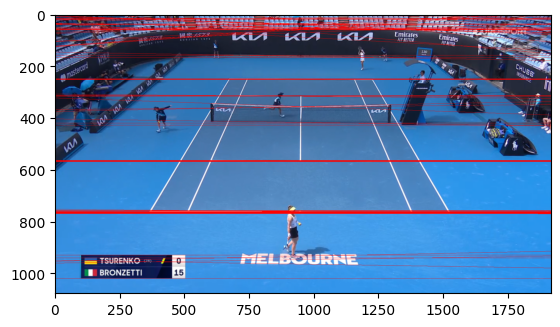

In [130]:
display_img(img_copy)

In [131]:
# poziome linie ale tylko na podstawie centralnych segmentow

lines = [Line.from_hough_line(*segment) for segment in filtered]
h_lines_filtered = [line for line in lines if line.slope is not None and abs(line.slope) < 0.1]

In [132]:
img_copy = img.copy()

for line in h_lines_filtered:

    p1, p2 = line.limit_to_img(img_copy)

    cv2.line(img_copy, p1, p2, (255, 0, 0), 1)

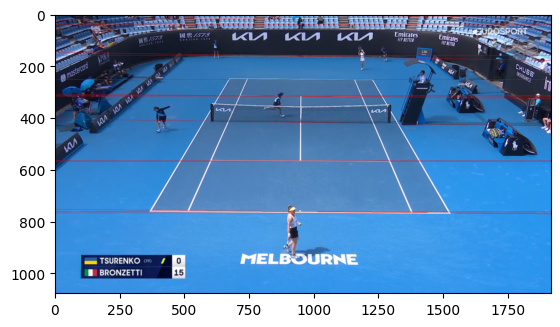

In [133]:
display_img(img_copy)

In [136]:
lines_group = group_lines(h_lines_filtered, thresh_intercept=25)

In [137]:
img_copy = img.copy()

for line in lines_group:

    p1, p2 = line.limit_to_img(img_copy)

    cv2.line(img_copy, p1, p2, (255, 0, 0), 1)

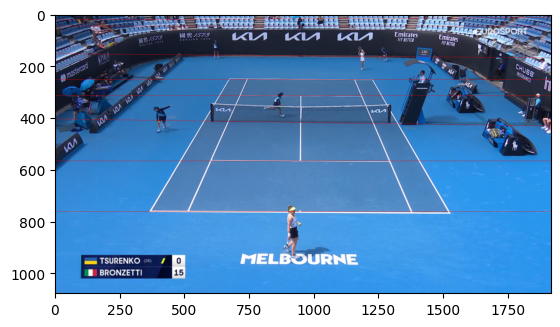

In [138]:
display_img(img_copy)

In [144]:
baseline, middleline, endline = sorted(lines_group, key= lambda line: line.intercept, reverse=True)[:3]

In [145]:
baseline

LineGroup: y = 0.00 * x + 763.00 (from 3 lines)